# Data Mining Project - Speed Dating Experiment Analysis - Modeling
 
**Authors:** Tomasz Kisielewski, Robert Gosz, Antoni Kiciński  
 **Dataset:** [Speed Dating Experiment](https://www.kaggle.com/datasets/annavictoria/speed-dating-experiment)

----

## 1. Dataset Overview

The Speed Dating Experiment dataset contains 8,378 records from 551 unique participants across 21 speed dating sessions. Each row represents a single 4-minute date from one participant's perspective. The target variable is `match` (binary: 1 = mutual match, 0 = no match), with a class imbalance of ~16.5% positive cases.

For this part of the project, we use the 23 columns selected in Part 1, covering post-date partner ratings, pre-event stated preferences, self-assessments, age, and gender.

---

## 2. Data Mining Goals (Quick Review)

**Primary goal:** Classify whether a speed date results in a mutual match (`match = 1`)

**Supporting goals:**
1. Identify which features most strongly predict a match (feature importance)
2. Analyze gender differences in model predictions
3. Compare stated preferences vs. actual feature importance (stated vs. revealed)
4. Examine whether self-ratings appear among top predictive features
5. Investigate the pickiness effect in the context of model predictions
6. Identify a 'golden client' profile most likely to result in a match

---

## 3. Modeling Strategy

**Chosen task:** Binary classification (`match = 1` vs `match = 0`)

**Algorithms to evaluate:**
- Random Forest - ensemble of decision trees, robust to outliers and skewed distributions
- Logistic Regression - simple linear baseline, highly interpretable
- Decision Tree - interpretable, can be visualized, easy to explain
- XGBoost - gradient boosting, typically strong on tabular data

All four models will be trained and evaluated on the same data. The best performing
model - based on F1-score for the Match class - will then be used for all further
experiments and supporting analyses.

**Evaluation method:** F1-score (primary), Accuracy, Confusion Matrix  
Due to class imbalance (~16.5% positive), accuracy alone is misleading - a model
predicting 'no match' every time would achieve 83.5% accuracy without learning
anything. F1-score for the positive class is therefore the main evaluation metric.

**Experiments planned (on the best model):**
- **Feature subset** - testing the model without `like` and `prob` to check whether
  these features inflate performance or whether the model genuinely learns from the
  remaining attributes
- **Class imbalance handling** - comparing SMOTE, `class_weight='balanced'` and no
  balancing to find the most effective strategy for detecting the minority class


---

## 4. Data Preparation

### 4.1 Load Data

In [1]:
import kagglehub
import pandas as pd
import numpy as np

path = kagglehub.dataset_download('annavictoria/speed-dating-experiment')
df = pd.read_csv(f'{path}/Speed Dating Data.csv', encoding='latin1')

key_cols = [
    'iid', 'gender', 'match',
    'dec', 'dec_o',
    'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob',
    'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1',
    'attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1',
    'age', 'age_o'
]

df = df[key_cols].copy()
print(df.shape)
print(df['match'].value_counts())

(8378, 26)
match
0    6998
1    1380
Name: count, dtype: int64


### 4.2 Missing Data - Imputation

Based on Part 1 findings:
- `shar` - 12.7% missing → median imputation
- `amb` - 8.5% missing → median imputation
- All other columns - below 5% → median imputation

We use median imputation as the distributions are skewed (not normal).

After loading the dataset, we select only the 23 columns relevant to our analytical
goals. Two columns are explicitly excluded from the feature set:

- `iid` - unique participant identifier, not a predictive feature; used only for
  the train/test split at participant level
- `dec` and `dec_o` - participant decisions which directly determine `match`
  (match = 1 only when dec = 1 AND dec_o = 1); including them caused perfect
  accuracy (100%) due to data leakag

In [2]:
from sklearn.impute import SimpleImputer
 
feature_cols = [
    'gender',
    'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob',
    'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1',
    'attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1',
    'age', 'age_o'
]
 
target_col = 'match'
 
# Sprawdz braki przed imputacja
print("=== Missing values before imputation ===")
print(df[feature_cols].isnull().sum()[df[feature_cols].isnull().sum() > 0])
 
# Median imputation (rozklady skosne wiec mediana lepsza niz srednia)
imputer = SimpleImputer(strategy='median')
df[feature_cols] = imputer.fit_transform(df[feature_cols])
 
print("\n=== Missing values after imputation ===")
print(df[feature_cols].isnull().sum().sum(), "missing values remaining")

=== Missing values before imputation ===
attr         202
sinc         277
intel        296
fun          350
amb          712
shar        1067
like         240
prob         309
attr1_1       79
sinc1_1       79
intel1_1      79
fun1_1        89
amb1_1        99
shar1_1      121
attr3_1      105
sinc3_1      105
intel3_1     105
fun3_1       105
amb3_1       105
age           95
age_o        104
dtype: int64

=== Missing values after imputation ===
0 missing values remaining


### 4.3 Train/Test Split

The dataset is split into 80% training and 20% test sets. An important consideration
here is that each participant appears in multiple rows - one per speed date. A naive
row-level split would cause data leakage, as the same participant could appear in
both train and test sets, allowing the model to "memorize" their behavior rather than
generalize.

To avoid this, the split is performed at the **participant level** (`iid`). All dates
belonging to a given participant are assigned exclusively to either the train or test
set - never both. This ensures that the model is evaluated on truly unseen participants.

In [3]:
from sklearn.model_selection import train_test_split
 
# Split po uczestnikach zeby uniknac data leakage
unique_iids = df['iid'].unique()
train_iids, test_iids = train_test_split(unique_iids, test_size=0.2, random_state=42)
 
train_df = df[df['iid'].isin(train_iids)]
test_df  = df[df['iid'].isin(test_iids)]
 
X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]
 
print(f"Train size: {len(X_train)} rows ({len(train_iids)} participants)")
print(f"Test size:  {len(X_test)} rows ({len(test_iids)} participants)")
print(f"\nMatch rate in train: {y_train.mean():.2%}")
print(f"Match rate in test:  {y_test.mean():.2%}")

Train size: 6625 rows (440 participants)
Test size:  1753 rows (111 participants)

Match rate in train: 16.17%
Match rate in test:  17.63%


- Train set: 440 participants, 6,625 rows (match rate: 16.17%)
- Test set: 111 participants, 1,753 rows (match rate: 17.63%)

The match rates are consistent between train and test, confirming that the split
did not introduce any significant bias.

---

## 5. Model Creation & Evaluation

In this section we train and evaluate four classification models on the same
train/test split. Each model is configured to handle class imbalance and evaluated
primarily on F1-score for the Match class, since accuracy alone is misleading given
the 16.5% positive rate.

The goal is to compare how each algorithm handles the binary classification of match
outcomes and select the best performing model for further experiments in Section 6
and supporting analyses in Section 7.

### 5.1 Random Forest (Main Model)

We train a Random Forest classifier with `class_weight='balanced'` to partially address 
the class imbalance (~16.5% positive cases). The model uses 100 decision trees and is 
evaluated on the test set using precision, recall, F1-score, and a confusion matrix.

=== Random Forest - Classification Report ===
              precision    recall  f1-score   support

    No Match       0.83      0.98      0.90      1444
       Match       0.42      0.08      0.14       309

    accuracy                           0.82      1753
   macro avg       0.63      0.53      0.52      1753
weighted avg       0.76      0.82      0.76      1753



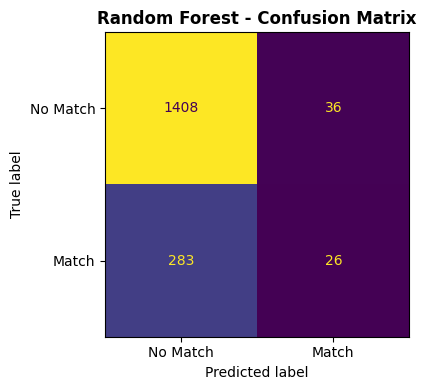

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

results = []

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
 
print("=== Random Forest - Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=['No Match', 'Match']))
 
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=['No Match', 'Match']).plot(ax=ax, colorbar=False)
ax.set_title('Random Forest - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_cm_rf.png', bbox_inches='tight')
plt.show()
 
results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'F1 (Match)': f1_score(y_test, y_pred_rf, pos_label=1)
})

**Key results:**
- Accuracy: 82% - misleading due to class imbalance (baseline = 83.5%)
- F1-score for Match: 0.14 - the model struggles to detect actual matches
- Out of 309 real matches, only 26 were correctly identified (recall = 8%)
- 283 matches were missed (False Negatives) - the main weakness of this model

**Confusion Matrix:**
- 1408 correctly predicted as No Match ✅
- 26 correctly predicted as Match ✅
- 283 missed matches (False Negatives) ❌
- 36 false alarms - predicted Match but no match occurred ❌

**Interpretation:**
Random Forest is very conservative - it rarely predicts a match, which keeps
precision relatively high (0.42) but at the cost of missing almost all real matches.
This behavior is typical for ensemble models on imbalanced data - the majority of
trees vote "no match" simply because most training examples are "no match", even
with `class_weight='balanced'`. The model prioritizes not making false alarms over
actually finding matches.

---

### 5.2 Decision Tree

The Decision Tree classifier with `max_depth=4` and `class_weight='balanced'` shows
a very different trade-off compared to Random Forest.

**Why max_depth=4?**
Limiting the tree depth prevents overfitting - a fully grown tree would memorize the
training data rather than learn generalizable patterns. Depth 4 keeps the model
interpretable while still capturing the most important decision rules, as visible
in the tree visualization below.

=== Decision Tree - Classification Report ===
              precision    recall  f1-score   support

    No Match       0.93      0.62      0.74      1444
       Match       0.30      0.77      0.43       309

    accuracy                           0.65      1753
   macro avg       0.61      0.69      0.59      1753
weighted avg       0.82      0.65      0.69      1753



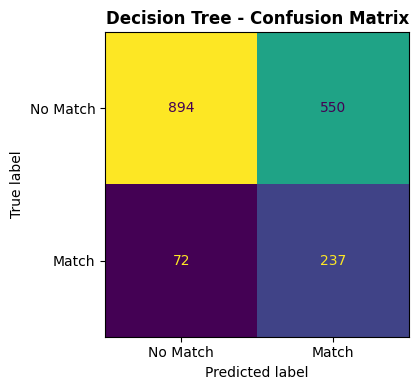

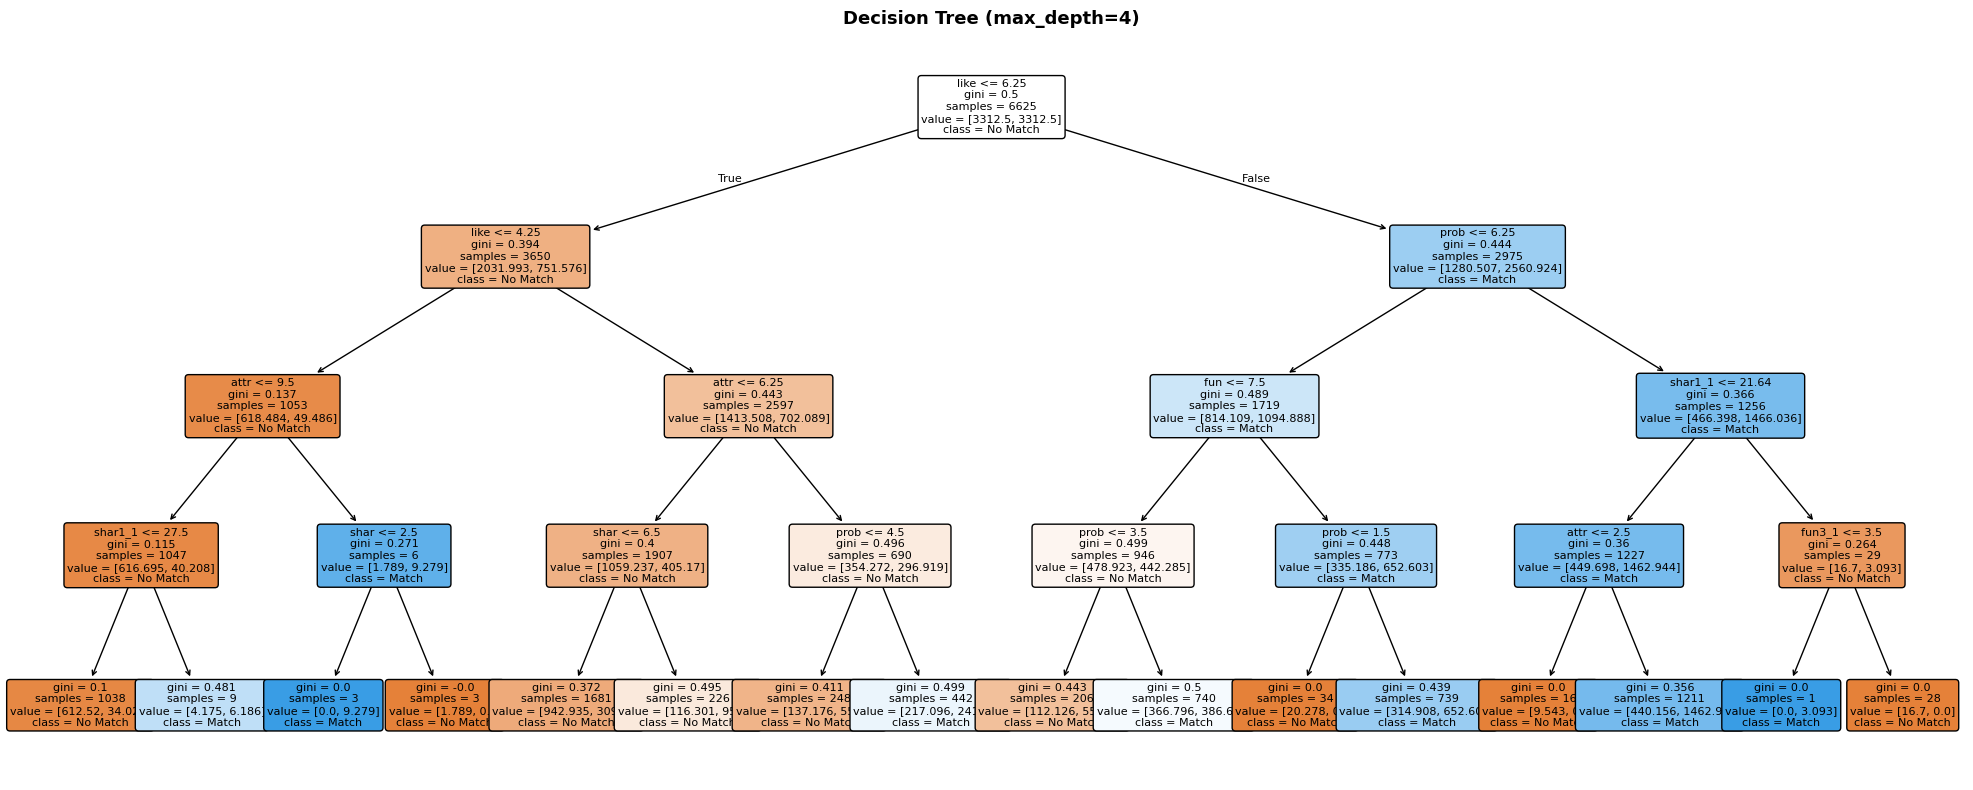

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=4)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
 
print("=== Decision Tree - Classification Report ===")
print(classification_report(y_test, y_pred_dt, target_names=['No Match', 'Match']))
 
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt),
                       display_labels=['No Match', 'Match']).plot(ax=ax, colorbar=False)
ax.set_title('Decision Tree - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_cm_dt.png', bbox_inches='tight')
plt.show()
 
# Wizualizacja drzewa
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=feature_cols, class_names=['No Match', 'Match'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree (max_depth=4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_decision_tree.png', bbox_inches='tight')
plt.show()
 
results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'F1 (Match)': f1_score(y_test, y_pred_dt, pos_label=1)
})

**Key results:**
- Accuracy: 65% - lower than Random Forest (82%), but accuracy is misleading here
- F1-score for Match: **0.43** - significantly better than Random Forest (0.14)
- Recall for Match: **77%** - the model correctly identifies 237 out of 309 real matches

**Confusion Matrix:**
- 894 correctly predicted as No Match ✅
- 237 correctly predicted as Match ✅
- 72 missed matches (False Negatives) ❌
- 550 false alarms - predicted Match but no match occurred ❌

**Tree structure:**
The root split on `like <= 6.25` confirms what EDA already suggested - overall liking
is the most decisive factor. The right branch (like > 6.25) then splits on `prob`,
while the left branch splits on `attr`. Shared interests (`shar`) and fun (`fun3_1`)
also appear at deeper levels, consistent with our correlation findings from Part 1.

**Interpretation:**
Decision Tree is much more aggressive in predicting matches than Random Forest.
It achieves high recall (catches most real matches) at the cost of low precision (0.30)
- meaning only 3 out of 10 predicted matches are real.

---

### 5.3 Logistic Regression

Logistic Regression is a linear classification model that estimates the probability
of a match based on a weighted combination of input features. Unlike tree-based
models, it assumes a linear relationship between features and the log-odds of the
target variable. Despite its simplicity, it is often competitive with more complex
models - especially when the dataset is not very large and the relationships are
roughly linear.

We use `class_weight='balanced'` to compensate for the class imbalance, and
`max_iter=1000` to ensure the optimization algorithm has enough iterations to
converge to a stable solution.


=== Logistic Regression - Classification Report ===
              precision    recall  f1-score   support

    No Match       0.91      0.73      0.81      1444
       Match       0.35      0.67      0.46       309

    accuracy                           0.72      1753
   macro avg       0.63      0.70      0.63      1753
weighted avg       0.81      0.72      0.75      1753



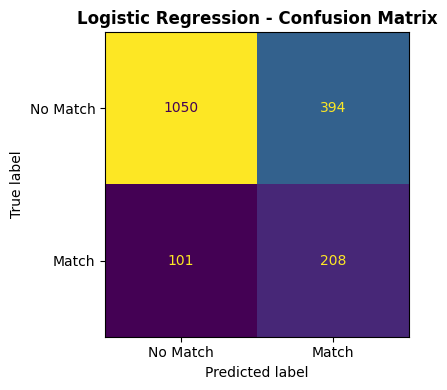

In [6]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
 
print("=== Logistic Regression - Classification Report ===")
print(classification_report(y_test, y_pred_lr, target_names=['No Match', 'Match']))
 
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=['No Match', 'Match']).plot(ax=ax, colorbar=False)
ax.set_title('Logistic Regression - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_cm_lr.png', bbox_inches='tight')
plt.show()
 
results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'F1 (Match)': f1_score(y_test, y_pred_lr, pos_label=1)
})

**Key results:**
- Accuracy: 72% - between Random Forest (82%) and Decision Tree (65%)
- F1-score for Match: **0.46** - best so far among all tested models
- Recall for Match: **67%** - correctly identifies 208 out of 309 real matches
- Precision for Match: 0.35 - better than Decision Tree (0.30)

**Confusion Matrix:**
- 1050 correctly predicted as No Match ✅
- 208 correctly predicted as Match ✅
- 101 missed matches (False Negatives) ❌
- 394 false alarms - predicted Match but no match occurred ❌

**Interpretation:**
Logistic Regression offers the best balance so far between precision and recall
for the Match class. Compared to Random Forest it misses far fewer matches
(101 vs 283), and compared to Decision Tree it generates fewer false alarms
(394 vs 550). As a simple linear model it is also the most interpretable -
making it a strong candidate for the best model so far.

---

### 5.4 XGBoost

XGBoost (Extreme Gradient Boosting) is an ensemble method that builds trees
sequentially - each new tree tries to correct the errors of the previous ones.
It is generally one of the strongest algorithms for tabular data. We use
`scale_pos_weight=5` to handle class imbalance, which tells the model to penalize
missed matches more heavily during training.

=== XGBoost - Classification Report ===
              precision    recall  f1-score   support

    No Match       0.87      0.85      0.86      1444
       Match       0.36      0.39      0.37       309

    accuracy                           0.77      1753
   macro avg       0.61      0.62      0.62      1753
weighted avg       0.78      0.77      0.77      1753



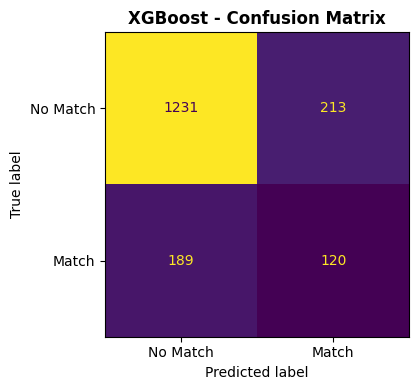

In [7]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42, scale_pos_weight=5, eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
 
print("=== XGBoost - Classification Report ===")
print(classification_report(y_test, y_pred_xgb, target_names=['No Match', 'Match']))
 
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb),
                       display_labels=['No Match', 'Match']).plot(ax=ax, colorbar=False)
ax.set_title('XGBoost - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_cm_xgb.png', bbox_inches='tight')
plt.show()
 
results.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'F1 (Match)': f1_score(y_test, y_pred_xgb, pos_label=1)
})

**Key results:**
- Accuracy: 77% - second best after Random Forest (82%)
- F1-score for Match: **0.37** - lower than Logistic Regression (0.46) and Decision Tree (0.43)
- Recall for Match: **39%** - correctly identifies 120 out of 309 real matches
- Precision for Match: 0.36 - similar to other models

**Confusion Matrix:**
- 1231 correctly predicted as No Match ✅
- 120 correctly predicted as Match ✅
- 189 missed matches (False Negatives) ❌
- 213 false alarms - predicted Match but no match occurred ❌

**Interpretation:**
Despite being a powerful algorithm, XGBoost underperforms here compared to
Logistic Regression. It finds a middle ground - better at avoiding false alarms
than Decision Tree (213 vs 550) but missing significantly more real matches than
Logistic Regression (189 vs 101). The relatively small dataset size and the
difficulty of tuning `scale_pos_weight` may explain why a simpler model like
Logistic Regression outperforms it here.

---

### 5.5 Model Comparison & Selection

All four models were trained and evaluated on the same train/test split.
The table below summarizes their performance, sorted by F1-score for the Match class.


=== Summary - All Models ===
              Model  Accuracy  F1 (Match)
Logistic Regression  0.717627    0.456641
      Decision Tree  0.645180    0.432482
            XGBoost  0.770679    0.373832
      Random Forest  0.818026    0.140162


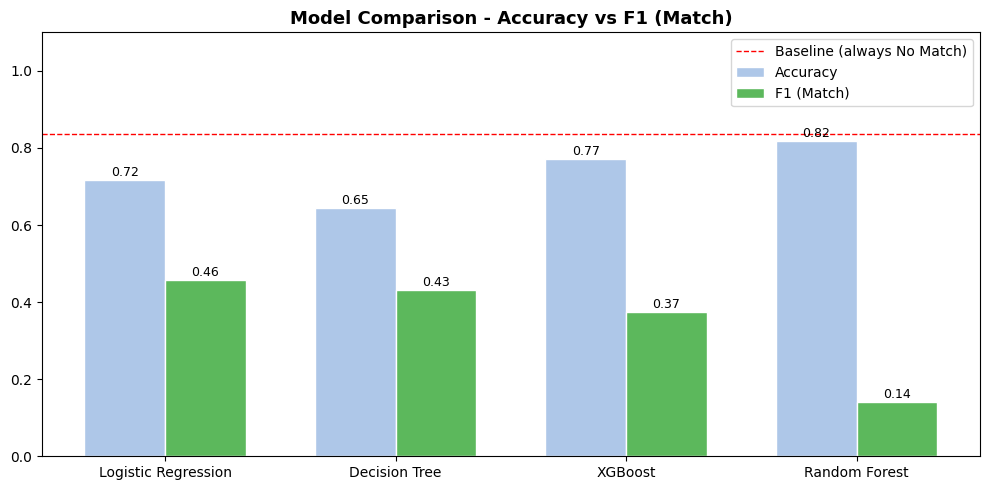

In [8]:
results_df = pd.DataFrame(results).sort_values('F1 (Match)', ascending=False)
print("=== Summary - All Models ===")
print(results_df.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results_df))
width = 0.35
 
bars1 = ax.bar([i - width/2 for i in x], results_df['Accuracy'], width,
               label='Accuracy', color='#aec7e8', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], results_df['F1 (Match)'], width,
               label='F1 (Match)', color='#5cb85c', edgecolor='white')
 
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison - Accuracy vs F1 (Match)', fontsize=13, fontweight='bold')
ax.axhline(0.835, color='red', linestyle='--', linewidth=1, label='Baseline (always No Match)')
ax.legend()
 
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
 
plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()

| Model | Accuracy | F1 (Match) |
|---|---|---|
| Logistic Regression | 0.72 | **0.46** |
| Decision Tree | 0.65 | 0.43 |
| XGBoost | 0.77 | 0.37 |
| Random Forest | 0.82 | 0.14 |

**Key observation:** Random Forest has the highest accuracy (0.82) but the worst F1
for the Match class (0.14) - it barely detects any matches. All models score below
the baseline accuracy (0.835), confirming that accuracy alone is a misleading metric
here.

**Winner: Logistic Regression** - best F1 (0.46) with a reasonable balance between
precision (0.35) and recall (0.67). Despite being the simplest model, it outperforms
all others on the metric that matters most for our goal.

Logistic Regression will be used as the main model for all further experiments
and supporting analyses in Section 6 and 7.

---

## 6. Experiments

In this section we run two experiments on the best performing model - Logistic
Regression - to test whether performance can be improved and to better understand
the role of individual features and class balancing strategies.


### 6.1 Feature Subset: Without `like` and `prob`

`like` (overall liking) and `prob` (estimated probability that the partner also said
yes) are both collected after the date - just like the target variable `match`.
There is a risk that these features are too strongly correlated with `match` and
inflate model performance rather than reflecting genuine predictive power. This
experiment tests whether the model performs similarly without them.

=== Logistic Regression - WITHOUT like and prob ===
              precision    recall  f1-score   support

    No Match       0.91      0.70      0.79      1444
       Match       0.33      0.69      0.45       309

    accuracy                           0.70      1753
   macro avg       0.62      0.70      0.62      1753
weighted avg       0.81      0.70      0.73      1753



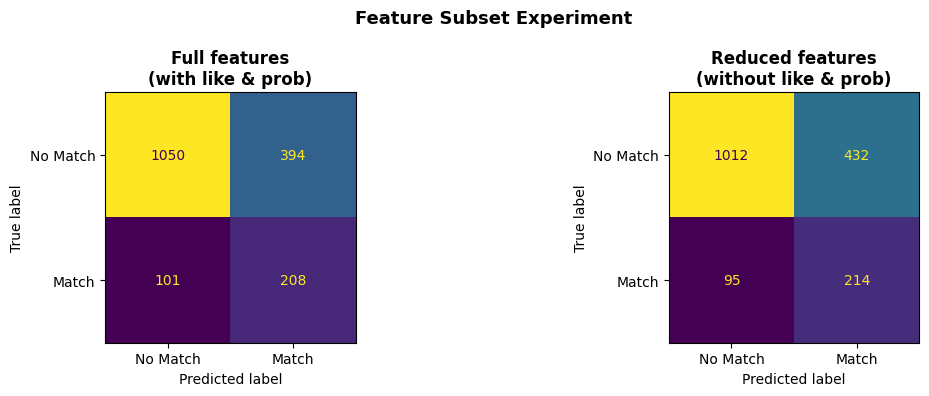


Full features     - F1 (Match): 0.457
Reduced features  - F1 (Match): 0.448


In [9]:
feature_cols_reduced = [c for c in feature_cols if c not in ['like', 'prob']]
 
X_train_red = train_df[feature_cols_reduced]
X_test_red  = test_df[feature_cols_reduced]
 
lr_red = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr_red.fit(X_train_red, y_train)
y_pred_red = lr_red.predict(X_test_red)
 
print("=== Logistic Regression - WITHOUT like and prob ===")
print(classification_report(y_test, y_pred_red, target_names=['No Match', 'Match']))
 
# Porownanie
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=['No Match', 'Match']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Full features\n(with like & prob)', fontweight='bold')
 
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_red),
                       display_labels=['No Match', 'Match']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Reduced features\n(without like & prob)', fontweight='bold')
 
plt.suptitle('Feature Subset Experiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_exp_feature_subset.png', bbox_inches='tight')
plt.show()
 
print(f"\nFull features     - F1 (Match): {f1_score(y_test, y_pred_lr, pos_label=1):.3f}")
print(f"Reduced features  - F1 (Match): {f1_score(y_test, y_pred_red, pos_label=1):.3f}")

| | Full features | Reduced features |
|---|---|---|
| F1 (Match) | **0.46** | 0.45 |
| Recall (Match) | 0.67 | 0.69 |
| Precision (Match) | 0.35 | 0.33 |
| Accuracy | 0.72 | 0.70 |

**Confusion Matrix - Full features:**
- 1050 correctly predicted as No Match ✅
- 208 correctly predicted as Match ✅
- 101 missed matches ❌
- 394 false alarms ❌

**Confusion Matrix - Reduced features:**
- 1012 correctly predicted as No Match ✅
- 214 correctly predicted as Match ✅
- 95 missed matches ❌
- 432 false alarms ❌

**Conclusion:**
Removing `like` and `prob` has almost no impact on performance - F1 drops by only
0.01 while recall slightly improves (0.67 → 0.69). This confirms that these features
were not artificially inflating the model. The remaining features capture enough
signal on their own, which gives us more confidence that the model is learning
genuine patterns rather than shortcuts.

---

### 6.2 Class Imbalance: SMOTE vs class_weight vs None

With only 16.5% positive cases, the model trained without any balancing tends to
ignore the Match class entirely - it is simply more "profitable" to always predict
No Match. We test three strategies to address this:

- **No balancing** - model trained on raw imbalanced data
- **class_weight='balanced'** - each Match example is weighted inversely proportional
  to class frequency, so the model penalizes missed matches more heavily during training.
  The data itself does not change - only the loss function is adjusted.
- **SMOTE** (Synthetic Minority Oversampling Technique) - new synthetic Match examples
  are generated by interpolating between existing ones, physically expanding the
  training set until both classes are balanced. Unlike class_weight, SMOTE changes
  the actual training data.

=== No balancing ===
              precision    recall  f1-score   support

    No Match       0.85      0.96      0.90      1444
       Match       0.53      0.19      0.28       309

    accuracy                           0.83      1753
   macro avg       0.69      0.58      0.59      1753
weighted avg       0.79      0.83      0.79      1753

=== class_weight='balanced' ===
              precision    recall  f1-score   support

    No Match       0.91      0.73      0.81      1444
       Match       0.35      0.67      0.46       309

    accuracy                           0.72      1753
   macro avg       0.63      0.70      0.63      1753
weighted avg       0.81      0.72      0.75      1753

=== SMOTE ===
              precision    recall  f1-score   support

    No Match       0.91      0.73      0.81      1444
       Match       0.34      0.66      0.45       309

    accuracy                           0.72      1753
   macro avg       0.63      0.69      0.63      1753
weighte

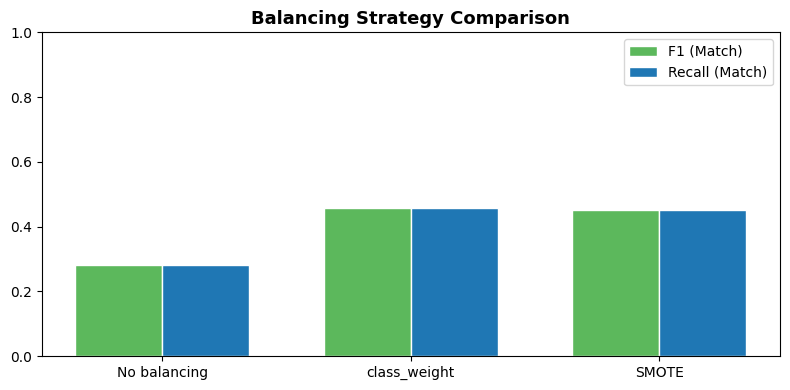

In [10]:
from imblearn.over_sampling import SMOTE
 
# Wersja 1 - bez balansowania
lr_none = LogisticRegression(random_state=42, max_iter=1000)
lr_none.fit(X_train, y_train)
y_pred_none = lr_none.predict(X_test)
 
# Wersja 2 - class_weight='balanced' (juz mamy jako lr)
# y_pred_lr z sekcji 5.3
 
# Wersja 3 - SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = lr_smote.predict(X_test)
 
print("=== No balancing ===")
print(classification_report(y_test, y_pred_none, target_names=['No Match', 'Match']))
print("=== class_weight='balanced' ===")
print(classification_report(y_test, y_pred_lr, target_names=['No Match', 'Match']))
print("=== SMOTE ===")
print(classification_report(y_test, y_pred_smote, target_names=['No Match', 'Match']))
 
# Porownanie
balancing_results = pd.DataFrame([
    {'Strategy': 'No balancing',        'F1 (Match)': f1_score(y_test, y_pred_none,  pos_label=1), 'Recall (Match)': f1_score(y_test, y_pred_none,  pos_label=1, average=None)[1]},
    {'Strategy': 'class_weight',        'F1 (Match)': f1_score(y_test, y_pred_lr,    pos_label=1), 'Recall (Match)': f1_score(y_test, y_pred_lr,    pos_label=1, average=None)[1]},
    {'Strategy': 'SMOTE',               'F1 (Match)': f1_score(y_test, y_pred_smote, pos_label=1), 'Recall (Match)': f1_score(y_test, y_pred_smote, pos_label=1, average=None)[1]},
])
 
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(balancing_results))
width = 0.35
ax.bar([i - width/2 for i in x], balancing_results['F1 (Match)'], width,
       label='F1 (Match)', color='#5cb85c', edgecolor='white')
ax.bar([i + width/2 for i in x], balancing_results['Recall (Match)'], width,
       label='Recall (Match)', color='#1f77b4', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(balancing_results['Strategy'])
ax.set_ylim(0, 1)
ax.set_title('Balancing Strategy Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_exp_balancing.png', bbox_inches='tight')
plt.show()

| Strategy | F1 (Match) | Recall (Match) | Precision (Match) |
|---|---|---|---|
| No balancing | 0.28 | 0.19 | 0.53 |
| class_weight='balanced' | **0.46** | **0.67** | 0.35 |
| SMOTE | 0.45 | 0.66 | 0.34 |

**Conclusion:**
Without any balancing the model almost completely ignores the Match class -
recall drops to just 19%, meaning it misses 4 out of 5 real matches. Both
`class_weight='balanced'` and SMOTE produce nearly identical results, with F1
around 0.46 and recall around 0.67. Since `class_weight` achieves the same
performance without modifying the training data, it remains the preferred strategy -
simpler and equally effective.

---

## 7. Goal Analyses

In this section we revisit all six analytical goals defined in Part 1 and address
them using the trained Logistic Regression model combined with the findings from
the exploratory analysis.

### 7.1 Main Goal - Match Classification

The primary goal of this project was to build a model capable of predicting whether
a speed date results in a mutual match. Based on the model comparison in Section 5,
Logistic Regression achieved the best F1-score of 0.46 for the Match class - meaning
it correctly identifies 67% of real matches while maintaining a reasonable precision
of 0.35.

Given the inherent difficulty of the task - mutual attraction between two people is
complex and subjective - an F1-score of 0.46 on a heavily imbalanced dataset
(16.5% positive) is a meaningful result. The model successfully learns patterns
from post-date ratings and participant characteristics, and performs significantly
better than a naive baseline that always predicts No Match.

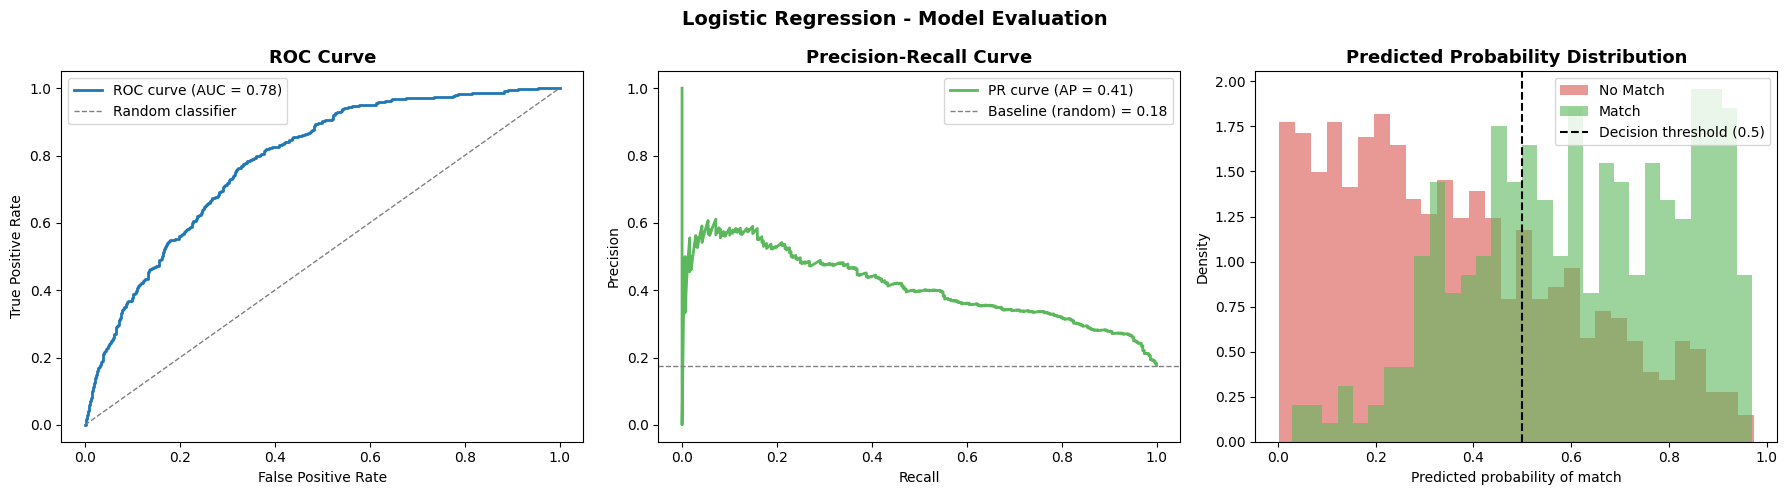

ROC AUC:          0.784
Average Precision: 0.411
Baseline AP:       0.176


In [11]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
 
y_prob = lr.predict_proba(X_test)[:, 1]
 
# ── ROC Curve ──
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].plot(fpr, tpr, color='#1f77b4', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend()
 
# ── Precision-Recall Curve ──
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
baseline = y_test.mean()
 
axes[1].plot(recall, precision, color='#5cb85c', linewidth=2, label=f'PR curve (AP = {ap:.2f})')
axes[1].axhline(baseline, color='gray', linestyle='--', linewidth=1,
                label=f'Baseline (random) = {baseline:.2f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].legend()
 
# ── Predicted Probabilities Distribution ──
prob_match    = y_prob[y_test == 1]
prob_no_match = y_prob[y_test == 0]
 
axes[2].hist(prob_no_match, bins=30, alpha=0.6, color='#d9534f', label='No Match', density=True)
axes[2].hist(prob_match,    bins=30, alpha=0.6, color='#5cb85c', label='Match',    density=True)
axes[2].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
axes[2].set_xlabel('Predicted probability of match')
axes[2].set_ylabel('Density')
axes[2].set_title('Predicted Probability Distribution', fontsize=13, fontweight='bold')
axes[2].legend()
 
plt.suptitle('Logistic Regression - Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_main_goal_evaluation.png', bbox_inches='tight')
plt.show()
 
print(f"ROC AUC:          {roc_auc:.3f}")
print(f"Average Precision: {ap:.3f}")
print(f"Baseline AP:       {baseline:.3f}")

The three plots above provide a deeper look at how the Logistic Regression model
performs beyond simple accuracy and F1-score.

**ROC Curve (AUC = 0.78)**
The ROC curve shows the trade-off between True Positive Rate (recall) and False
Positive Rate at different classification thresholds. AUC of 0.78 means the model
has a 78% chance of correctly ranking a random match above a random no-match.
This is a solid result - significantly above the random classifier baseline (AUC = 0.5).

**Precision-Recall Curve (AP = 0.41)**
The PR curve is more informative for imbalanced datasets. Our model achieves an
Average Precision of 0.41, compared to the random baseline of 0.18 - more than
double. The curve shows that at higher recall values precision drops, reflecting
the fundamental trade-off we observed in the confusion matrices.

**Predicted Probability Distribution**
The histogram shows how the model distributes predicted match probabilities for
actual matches (green) and non-matches (red). The two distributions overlap
significantly, which explains the moderate F1-score - the model finds it genuinely
difficult to separate the two classes. However, matches tend to receive higher
predicted probabilities on average, confirming the model has learned meaningful
patterns.

---

### 7.2 Gender Differences in Model Predictions

In Part 1 we observed that men say "yes" significantly more often than women
(47.4% vs 36.5%), suggesting that women are more selective. Here we go further
and examine whether this selectivity also affects how well the model predicts
matches for each gender separately.

=== Women ===
              precision    recall  f1-score   support

    No Match       0.91      0.74      0.82       779
       Match       0.38      0.69      0.49       176

    accuracy                           0.74       955
   macro avg       0.65      0.72      0.66       955
weighted avg       0.82      0.74      0.76       955

=== Men ===
              precision    recall  f1-score   support

    No Match       0.91      0.71      0.80       665
       Match       0.31      0.65      0.42       133

    accuracy                           0.70       798
   macro avg       0.61      0.68      0.61       798
weighted avg       0.81      0.70      0.73       798



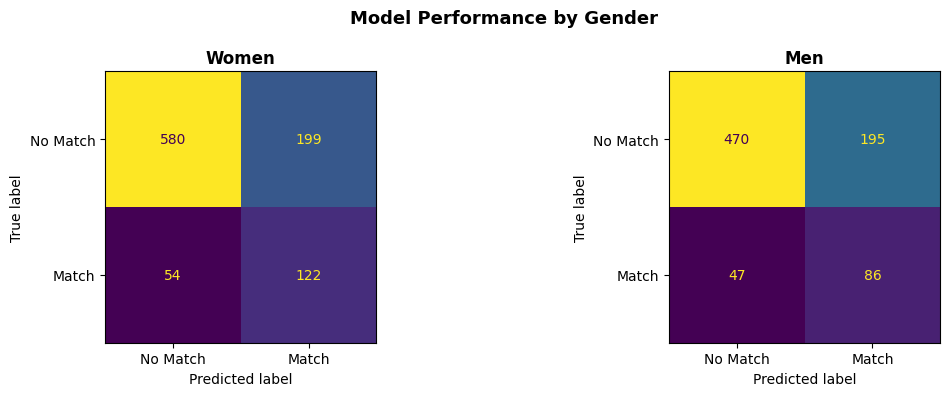

In [12]:
for gender, label in [(0, 'Women'), (1, 'Men')]:
    mask = test_df['gender'] == gender
    X_g = test_df.loc[mask, feature_cols]
    y_g = y_test[mask]
    y_pred_g = lr.predict(X_g)
 
    f1 = f1_score(y_g, y_pred_g, pos_label=1)
    acc = accuracy_score(y_g, y_pred_g)
    print(f"=== {label} ===")
    print(classification_report(y_g, y_pred_g, target_names=['No Match', 'Match']))
 
# Wykres porownawczy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (gender, label) in zip(axes, [(0, 'Women'), (1, 'Men')]):
    mask = test_df['gender'] == gender
    y_g = y_test[mask]
    y_pred_g = lr.predict(test_df.loc[mask, feature_cols])
    ConfusionMatrixDisplay(confusion_matrix(y_g, y_pred_g),
                           display_labels=['No Match', 'Match']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{label}', fontweight='bold')
 
plt.suptitle('Model Performance by Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_gender_performance.png', bbox_inches='tight')
plt.show()

| | Women | Men |
|---|---|---|
| F1 (Match) | **0.49** | 0.42 |
| Recall (Match) | **0.69** | 0.65 |
| Precision (Match) | 0.38 | 0.31 |
| Accuracy | 0.74 | 0.70 |

**Confusion Matrix - Women:**
- 580 correctly predicted as No Match ✅
- 122 correctly predicted as Match ✅
- 54 missed matches ❌
- 199 false alarms ❌

**Confusion Matrix - Men:**
- 470 correctly predicted as No Match ✅
- 86 correctly predicted as Match ✅
- 47 missed matches ❌
- 195 false alarms ❌

**Conclusion:**
The model performs better for women (F1=0.49) than for men (F1=0.42). This is
consistent with the EDA finding - women are more selective, meaning their "yes"
decisions are more strongly tied to specific partner characteristics that the model
can learn. Men say "yes" more freely, making their decisions harder to predict from
ratings alone. The gender gap observed in Part 1 is therefore not just a behavioral
difference - it also translates into a measurable difference in model predictability.

---

### 7.3 Stated vs. Revealed Preferences

In Part 1 we found that stated preferences - what participants said they value in
a partner before the event - show near-zero correlations with actual match outcomes.
Here we confirm this finding using the Logistic Regression model's feature importance
(absolute coefficient values) as a measure of what actually drives match predictions.

The chart below compares three perspectives on trait importance:
- **Stated** - what participants said they value in a partner before the event
- **EDA correlation** - which partner ratings most strongly correlated with match (Part 1)
- **Model importance** - which post-date ratings the Logistic Regression model weighted
  most heavily when predicting a match

Note: stated preferences reflect what participants declared they want, while EDA
correlation and model importance both reflect how the partner was actually rated
after the date - these are fundamentally different measurements, which is precisely
what makes the comparison interesting.

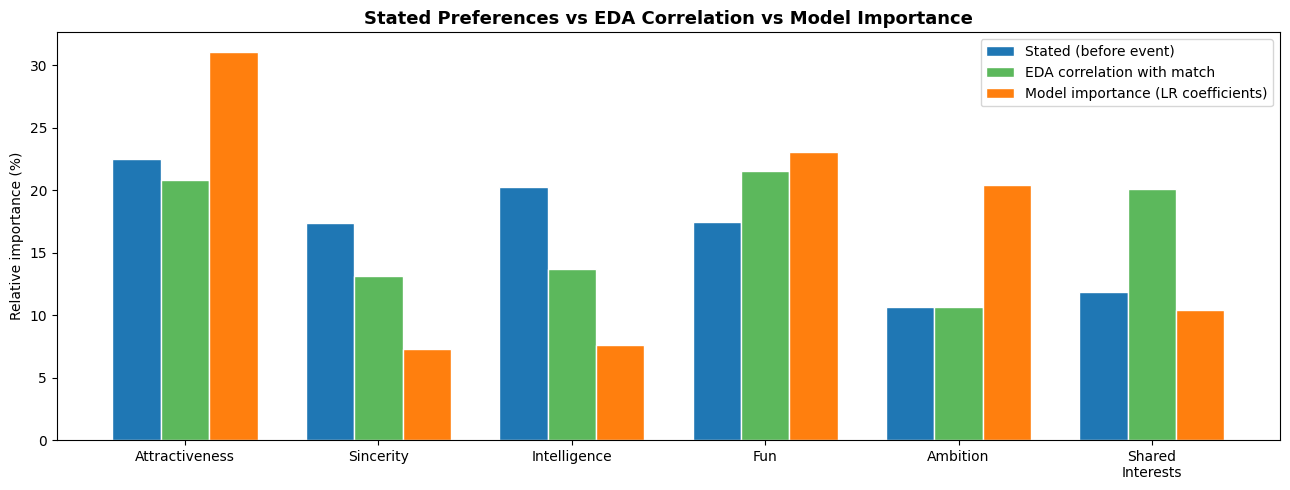

In [13]:
from matplotlib.patches import Patch
 
pref_cols  = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
rating_cols = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
labels = ['Attractiveness', 'Sincerity', 'Intelligence', 'Fun', 'Ambition', 'Shared\nInterests']
 
# Stated - co ludzie deklarowali przed eventem
stated = df[pref_cols].mean().values
 
# EDA correlation - korelacja ocen partnera z match (z Part 1)
eda_corr = np.array([df[c].corr(df['match']) for c in rating_cols])
eda_corr_norm = (eda_corr / eda_corr.sum()) * 100
 
# Model importance - wspolczynniki LR dla ocen partnera
revealed = np.abs(lr.coef_[0])[[feature_cols.index(c) for c in rating_cols]]
revealed_norm = (revealed / revealed.sum()) * 100
 
x = np.arange(len(labels))
width = 0.25
 
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, stated, width, label='Stated (before event)', color='#1f77b4', edgecolor='white')
ax.bar(x, eda_corr_norm, width, label='EDA correlation with match', color='#5cb85c', edgecolor='white')
ax.bar(x + width, revealed_norm, width, label='Model importance (LR coefficients)', color='#ff7f0e', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Relative importance (%)')
ax.set_title('Stated Preferences vs EDA Correlation vs Model Importance',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_stated_vs_revealed_model.png', bbox_inches='tight')
plt.show()

**Key findings:**
- **Attractiveness** is the most over-stated trait - declared most important (~22%)
  yet model assigns it the highest importance too (31%), but EDA correlation puts it
  in line with fun. Interestingly, the model appears to weight it more than raw
  correlation suggests.
- **Fun** is consistently important across all three perspectives - stated (~17%),
  EDA (~21%), model (~23%). This is the most "honest" trait - people value it,
  it correlates with match, and the model confirms it.
- **Sincerity and Intelligence** are over-stated - declared important (~17-20%) but
  both EDA correlation and model importance rank them at the bottom (~7-13%).
- **Ambition** is under-stated (~11%) but the model assigns it surprisingly high
  importance (~20%), which was not visible in the EDA correlation alone.

**Conclusion:**
EDA correlation and model importance broadly agree with each other, both diverging
significantly from stated preferences. This confirms that what people say they want
and what actually drives their decisions are two different things - a finding
consistent across both the exploratory and modeling phases.

---

### 7.4 Self-Assessment in Top Features

In Part 1 we found that self-ratings (`attr3_1`, `sinc3_1`, `intel3_1`, `fun3_1`,
`amb3_1`) show near-zero correlations with match outcomes (all below 0.05). Here
we verify and extend this finding using the Logistic Regression model's feature
importance - checking not just whether self-ratings correlate with match, but how
much weight the model actually assigns them compared to other features.

The chart below shows all 22 features ranked by their absolute coefficient value,
color-coded by group.

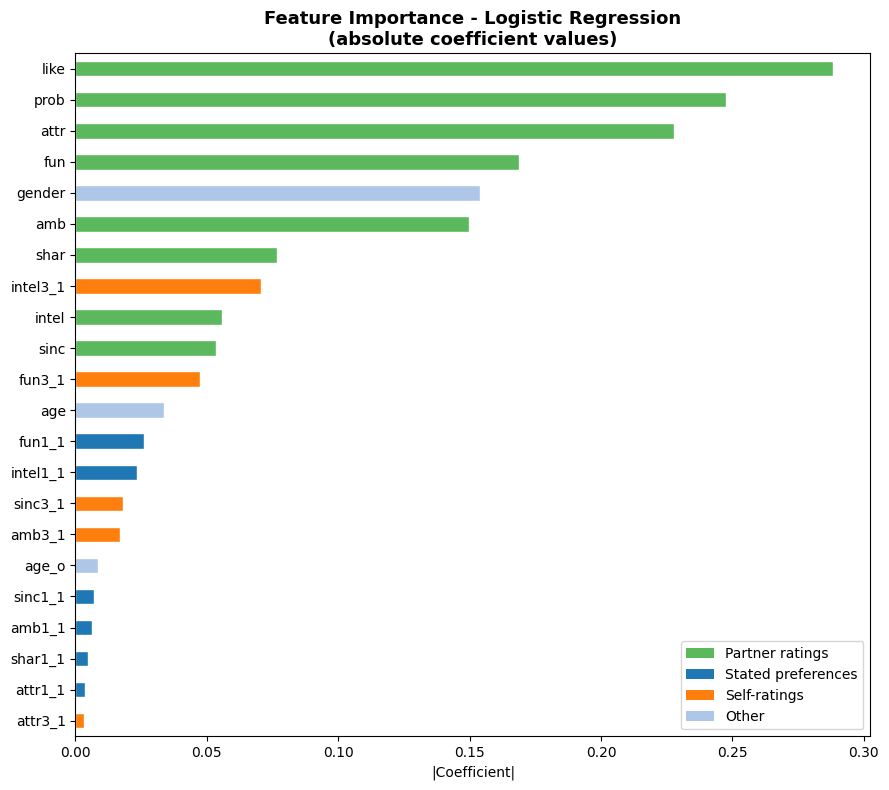

=== Feature Importance Ranking ===
 1. like         0.2881
 2. prob         0.2474
 3. attr         0.2278
 4. fun          0.1689
 5. gender       0.1540
 6. amb          0.1498
 7. shar         0.0766
 8. intel3_1     0.0707 ← SELF-RATING
 9. intel        0.0559
10. sinc         0.0534
11. fun3_1       0.0475 ← SELF-RATING
12. age          0.0335
13. fun1_1       0.0262
14. intel1_1     0.0235
15. sinc3_1      0.0182 ← SELF-RATING
16. amb3_1       0.0170 ← SELF-RATING
17. age_o        0.0085
18. sinc1_1      0.0070
19. amb1_1       0.0064
20. shar1_1      0.0049
21. attr1_1      0.0038
22. attr3_1      0.0034 ← SELF-RATING


In [14]:
self_cols = ['attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1']
 
# Feature importance z kolorowaniem
coef = pd.Series(np.abs(lr.coef_[0]), index=feature_cols).sort_values(ascending=True)
 
color_map = {}
for col in feature_cols:
    if col in ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob']:
        color_map[col] = '#5cb85c'
    elif col.endswith('1_1'):
        color_map[col] = '#1f77b4'
    elif col.endswith('3_1'):
        color_map[col] = '#ff7f0e'
    else:
        color_map[col] = '#aec7e8'
 
colors = [color_map[c] for c in coef.index]
 
fig, ax = plt.subplots(figsize=(9, 8))
coef.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance - Logistic Regression\n(absolute coefficient values)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('|Coefficient|')
 
legend_elements = [
    Patch(facecolor='#5cb85c', label='Partner ratings'),
    Patch(facecolor='#1f77b4', label='Stated preferences'),
    Patch(facecolor='#ff7f0e', label='Self-ratings'),
    Patch(facecolor='#aec7e8', label='Other'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()
 
# Ranking z oznaczeniem self-ratings
print("=== Feature Importance Ranking ===")
coef_sorted = coef.sort_values(ascending=False)
for i, (col, val) in enumerate(coef_sorted.items()):
    tag = " ← SELF-RATING" if col in self_cols else ""
    print(f"{i+1:2d}. {col:<12} {val:.4f}{tag}")

The feature importance chart above shows the absolute coefficient values from the
Logistic Regression model, color-coded by feature group: partner ratings (green),
stated preferences (blue), self-ratings (orange), and other variables (light blue).

**Key findings:**
- The top features are dominated by **partner ratings** - `like`, `prob`, `attr`,
  `fun`, `amb`, and `shar` all rank in the top 7
- **`gender`** appears surprisingly high (rank 5), suggesting that the model picks
  up a systematic difference in match patterns between men and women
- **Self-ratings** are scattered across the lower half of the ranking - `intel3_1`
  (rank 8) and `fun3_1` (rank 11) are the strongest self-rating predictors, but
  their coefficients are still several times smaller than the top partner ratings
- The weakest self-rating is `attr3_1` - how attractive you think you are has
  virtually no predictive value according to the model
- **Stated preferences** (`attr1_1`, `sinc1_1` etc.) consistently appear at the
  very bottom of the ranking, confirming the finding from 7.3

**Conclusion:**
Self-ratings have minimal predictive power for match outcomes. The model confirms
what EDA suggested in Part 1 - how you perceive yourself is largely irrelevant to
whether someone will mutually like you. What matters is how your date actually
experiences you during the 4-minute conversation, not your self-image. Partner
ratings are the dominant signal, and self-ratings add almost no information on top
of that.

---

### 7.5 Pickiness Effect - Extended Analysis

In Part 1 we found a correlation of 0.48 between a participant's yes rate and their
actual match rate. Here we extend this analysis by adding a model perspective.

For each participant in the test set we compute:
- **Yes rate** - the proportion of dates where they said "yes" (e.g. 7 out of 10 = 0.7)
- **Actual match rate** - the proportion of dates that resulted in a mutual match
- **Avg predicted match probability** - the average probability assigned by the model
  across all their dates, based purely on their characteristics and partner ratings

The two scatter plots compare yes rate against actual match rate (left) and against
model-predicted probability (right). Each dot represents one participant.

The key question is: does the model explain the pickiness effect, or is it mostly
a mathematical artifact of saying "yes" more often?

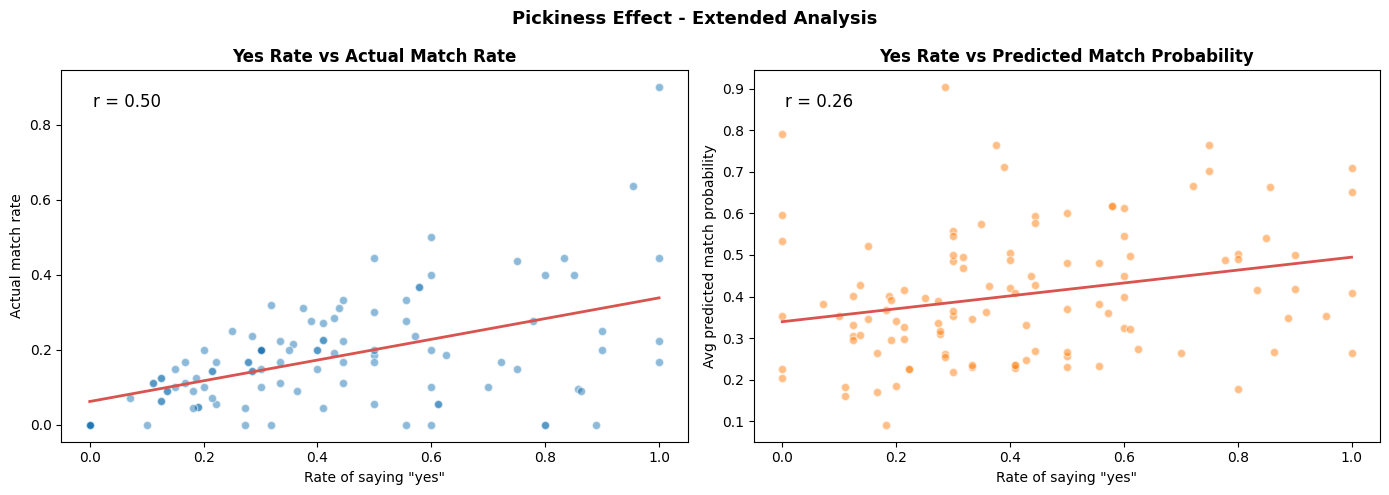

In [15]:
# Per participant: yes rate + predicted match probability
test_df = test_df.copy()
test_df['match_prob'] = lr.predict_proba(X_test)[:, 1]

# Dolacz dec z oryginalnego df (nie ma go w feature_cols)
dec_by_iid = df[df['iid'].isin(test_iids)].groupby('iid')['dec'].mean().reset_index()
dec_by_iid.columns = ['iid', 'yes_rate']

person_stats = test_df.groupby('iid').agg(
    match_rate=('match', 'mean'),
    avg_match_prob=('match_prob', 'mean')
).reset_index().merge(dec_by_iid, on='iid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Yes rate vs actual match rate
axes[0].scatter(person_stats['yes_rate'], person_stats['match_rate'],
                alpha=0.5, color='#1f77b4', edgecolors='white')
m, b = np.polyfit(person_stats['yes_rate'], person_stats['match_rate'], 1)
x_line = np.linspace(0, 1, 100)
axes[0].plot(x_line, m*x_line+b, color='#d9534f', linewidth=2)
axes[0].set_xlabel('Rate of saying "yes"')
axes[0].set_ylabel('Actual match rate')
axes[0].set_title('Yes Rate vs Actual Match Rate', fontweight='bold')
r = person_stats['yes_rate'].corr(person_stats['match_rate'])
axes[0].text(0.05, 0.9, f'r = {r:.2f}', transform=axes[0].transAxes, fontsize=12)

# Yes rate vs predicted match probability
axes[1].scatter(person_stats['yes_rate'], person_stats['avg_match_prob'],
                alpha=0.5, color='#ff7f0e', edgecolors='white')
m2, b2 = np.polyfit(person_stats['yes_rate'], person_stats['avg_match_prob'], 1)
axes[1].plot(x_line, m2*x_line+b2, color='#d9534f', linewidth=2)
axes[1].set_xlabel('Rate of saying "yes"')
axes[1].set_ylabel('Avg predicted match probability')
axes[1].set_title('Yes Rate vs Predicted Match Probability', fontweight='bold')
r2 = person_stats['yes_rate'].corr(person_stats['avg_match_prob'])
axes[1].text(0.05, 0.9, f'r = {r2:.2f}', transform=axes[1].transAxes, fontsize=12)

plt.suptitle('Pickiness Effect - Extended Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_pickiness_extended.png', bbox_inches='tight')
plt.show()

**Left plot - Yes Rate vs Actual Match Rate (r = 0.50):**
The positive correlation confirms the finding from Part 1. Participants who say
"yes" more often achieve more matches in reality. The relationship is noisy but
consistent - even controlling for individual variation, less selective participants
tend to end up with more mutual matches.

**Right plot - Yes Rate vs Predicted Match Probability (r = 0.26):**
This is the more interesting finding. The model assigns higher predicted match
probabilities to less selective participants, but the correlation is notably weaker
(0.26 vs 0.50). This tells us something important - the model only partially
captures the pickiness effect. The remaining correlation in the actual data is likely
driven by a simple mathematical effect: saying "yes" to more people increases the
chance that at least some say "yes" back, regardless of individual characteristics.

**Conclusion:**
The pickiness effect is real but has two components - one that the model can learn
from (participant characteristics that make them more likely to match) and one that
is purely mathematical (more yes decisions = more chances for a mutual yes). The
gap between r=0.50 and r=0.26 suggests that roughly half of the pickiness effect
comes from this mathematical component rather than genuine predictive patterns.

---

### 7.6 Golden Client Profile

The "golden client" is defined as the top 20% of dates ranked by the model's
predicted match probability. This group represents the profile of a participant
most likely to result in a mutual match according to the Logistic Regression model.

=== Golden Client - Top 10 Profiles ===
 match_prob gender  age  attr  fun  like  shar  prob  match
   0.973189      M 21.0  10.0 10.0  10.0  10.0  10.0      0
   0.970613      F 23.0  10.0 10.0  10.0  10.0  10.0      0
   0.970369      F 23.0  10.0 10.0  10.0  10.0  10.0      1
   0.970123      F 23.0  10.0 10.0  10.0  10.0  10.0      1
   0.969875      F 23.0  10.0 10.0  10.0  10.0  10.0      0
   0.966797      F 26.0   9.0 10.0   9.0   8.0  10.0      0
   0.965329      F 25.0  10.0 10.0   9.0   7.0  10.0      1
   0.965075      F 23.0  10.0 10.0  10.0   6.0   9.0      1
   0.960887      F 23.0  10.0 10.0  10.0  10.0   9.0      1
   0.960565      F 23.0  10.0 10.0  10.0  10.0   9.0      0

=== Golden Client - Average Profile (top 20%, n=351) ===
gender:  F (F: 186    M: 165)
age      26.13
attr      8.04
sinc      8.21
intel     8.39
fun       8.41
amb       7.75
shar      7.53
like      8.24
prob      7.55

Match rate - golden group: 41.03%
Match rate - overall:      17.63%


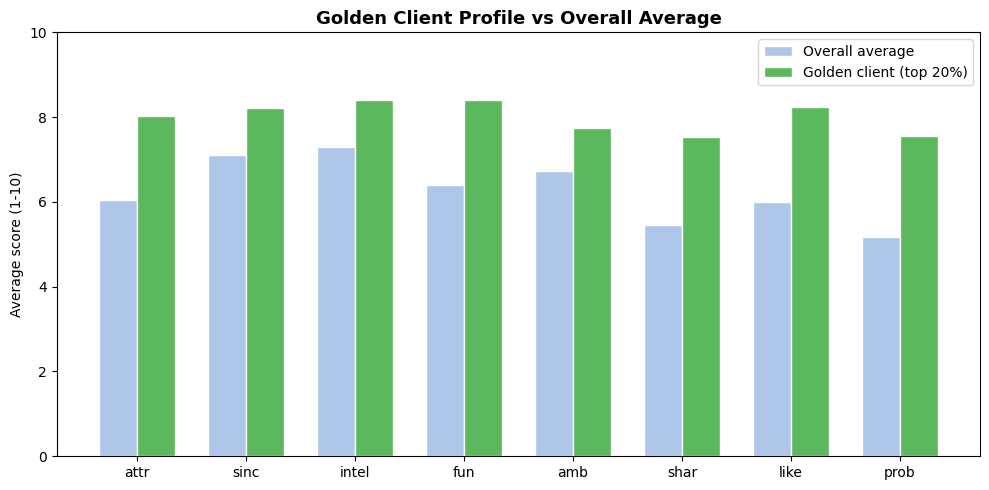

In [16]:

test_df['match_prob'] = lr.predict_proba(X_test)[:, 1]
 
# Top 10 rekordow
top10 = test_df.nlargest(10, 'match_prob')[
    ['match_prob', 'gender', 'age', 'attr', 'fun', 'like', 'shar', 'prob', 'match']
]
top10_display = top10.copy()
top10_display['gender'] = top10_display['gender'].map({0.0: 'F', 1.0: 'M'})
print("=== Golden Client - Top 10 Profiles ===")
print(top10_display.to_string(index=False))

# Sredni profil top 20%
threshold = test_df['match_prob'].quantile(0.8)
golden = test_df[test_df['match_prob'] >= threshold]
profile_cols = ['gender', 'age', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob']
 
golden_display = golden.copy()
golden_display['gender'] = golden_display['gender'].map({0.0: 'F', 1.0: 'M'})

gender_counts = golden_display['gender'].value_counts()
dominant = gender_counts.idxmax()

print(f"\n=== Golden Client - Average Profile (top 20%, n={len(golden)}) ===")
print(f"gender:  {dominant} (F: {gender_counts[dominant]}    M: {len(golden)-gender_counts[dominant]})")
print(golden[['age', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob']].mean().round(2).to_string())
print(f"\nMatch rate - golden group: {golden['match'].mean():.2%}")
print(f"Match rate - overall:      {test_df['match'].mean():.2%}")
 
# Wizualizacja profilu
fig, ax = plt.subplots(figsize=(10, 5))
rating_profile_cols = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob']
golden_means = golden[rating_profile_cols].mean()
overall_means = test_df[rating_profile_cols].mean()
 
x = np.arange(len(rating_profile_cols))
width = 0.35
ax.bar(x - width/2, overall_means, width, label='Overall average', color='#aec7e8', edgecolor='white')
ax.bar(x + width/2, golden_means, width, label='Golden client (top 20%)', color='#5cb85c', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(rating_profile_cols)
ax.set_ylim(0, 10)
ax.set_ylabel('Average score (1-10)')
ax.set_title('Golden Client Profile vs Overall Average', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_golden_client.png', bbox_inches='tight')
plt.show()

**Top 10 highest predicted probabilities:**
The model is most confident about dates where the partner received near-perfect
ratings across all traits - attractiveness, fun, shared interests and overall liking
all at 10/10. 9 out of 10 top profiles are women, aged 21–26. Interestingly, not
all of these dates resulted in an actual match (match=0 in several cases), which
reflects the fundamental difficulty of predicting mutual attraction.

**Average Golden Client Profile (top 20%, n=351):**

| Trait | Golden Client | Overall Average |
|---|---|---|
| Age | 26.1 | 26.53 |
| Attractiveness | 8.04 | 6.03 |
| Sincerity | 8.21 | 7.04 |
| Intelligence | 8.39 | 7.28 |
| Fun | 8.41 | 6.38 |
| Ambition | 7.75 | 6.70 |
| Shared Interests | 7.53 | 5.49 |
| Like | 8.24 | 6.01 |
| Prob | 7.55 | 5.13 |

**Gender:** Slightly more women (186F vs 165M), consistent with the finding that
women's decisions are more predictable by the model.

**Match rate:** The golden group achieves a match rate of **41.03%** compared to
**17.63%** overall - more than double. This confirms that the model successfully
identifies dates with genuinely higher mutual attraction potential.

**Profile Chart:**
The bar chart above visualizes the difference between the golden client profile
(green) and the overall average (blue) across all eight post-date rating dimensions.
The gap is consistent across all traits - golden clients score higher in every
category without exception. The largest differences are visible in shared interests
(+2.04), attractiveness (+2.01) and overall liking (+2.23), while the smallest
gap appears in ambition (+1.05) and intelligence (+1.11). This suggests that being
perceived as fun, likeable and sharing common interests with your date are the
strongest differentiators between an average date and one likely to result in a match.

**Conclusion:**
The golden client profile is someone who is rated highly across all traits by their
date - particularly fun, intelligence and overall liking - with scores consistently
above 8/10. The biggest gap between golden clients and average participants is in
shared interests (7.53 vs 5.49) and overall liking (8.24 vs 6.01), suggesting these
are the most discriminating factors for high match probability.

---

## 8. Summary & Conclusions

### 8.1 Best Performing Model
 
We evaluated four classification models on the same train/test split, using F1-score
for the Match class as the primary metric - accuracy alone is misleading given the
16.5% class imbalance.
 
| Model | Accuracy | F1 (Match) | Recall (Match) |
|---|---|---|---|
| Logistic Regression | 0.72 | **0.46** | 0.67 |
| Decision Tree | 0.65 | 0.43 | 0.77 |
| XGBoost | 0.77 | 0.37 | 0.39 |
| Random Forest | 0.82 | 0.14 | 0.08 |
 
**Logistic Regression** emerged as the best model with F1=0.46 and AUC=0.78.
Despite being the simplest of the four, it correctly identified 208 out of 309 real
matches (recall=0.67) while keeping a reasonable precision of 0.35 - meaning roughly
1 in 3 predicted matches was genuine.
 
Random Forest had the highest accuracy (0.82) but was practically useless for our
goal - it detected only 26 out of 309 matches (recall=0.08), defaulting to predicting
"no match" almost every time. Decision Tree achieved the highest recall (0.77) but
at the cost of 550 false alarms. XGBoost sat between the two without excelling at
either metric.
 
The AUC of 0.78 confirms that Logistic Regression has genuine discriminative power -
it has a 78% chance of correctly ranking a random match above a random no-match,
well above the 0.5 random baseline. The Precision-Recall curve (AP=0.41) is more
than double the random baseline of 0.18, further confirming the model learns
meaningful patterns rather than noise.

---

### 8.2 Experiments
 
Two experiments were conducted on the best model to test specific hypotheses:
 
**Experiment 1 - Feature subset without `like` and `prob`**
The motivation was to test whether these two features - both collected after the
date, just like the target variable - were artificially inflating model performance
by acting as shortcuts rather than genuine predictors. Removing them had almost no
impact: F1 dropped from 0.46 to 0.45 and recall slightly improved (0.67 → 0.69).
This is an important finding - it means the model is not cheating. The remaining
features (partner ratings, preferences, age) carry enough signal on their own, and
`like` and `prob` are not the reason the model works.
 
**Experiment 2 - Class imbalance: SMOTE vs class_weight vs None**
The motivation was to find the most effective strategy for handling the 16.5%
positive rate. Without any balancing, recall collapsed to just 19% - the model
ignored the Match class almost entirely. Both `class_weight='balanced'` and SMOTE
recovered performance to F1≈0.46 and recall≈0.67, with virtually no difference
between them. Since `class_weight` achieves identical results without modifying
the training data, it is the preferred strategy - simpler and equally effective.
 
---

### 8.3 Goal Analyses
 
**Main goal - Match classification:**
The primary goal was achieved. Logistic Regression predicts mutual matches with
F1=0.46 and AUC=0.78 on an inherently difficult imbalanced problem. Given that
mutual romantic attraction is complex and subjective, these results demonstrate
that measurable patterns exist and can be learned from speed dating data.
 
**Gender differences:**
The model performs better for women (F1=0.49) than men (F1=0.42). Women's more
selective behavior - saying "yes" in only 36.5% of dates vs 47.4% for men - means
their decisions are more consistently tied to specific partner characteristics,
making them more predictable. Gender itself ranks as the 5th most important feature,
confirming a systematic difference in match patterns between the two groups.
 
**Stated vs. revealed preferences:**
Both EDA correlation and model importance broadly agree with each other, and both
diverge significantly from stated preferences. Fun is the most "honest" trait -
people value it, it correlates with match, and the model assigns it high importance.
Sincerity and intelligence are systematically over-stated: declared as important by
participants but ranked at the bottom by both the model and the EDA. What people say
they want and what actually drives their romantic decisions are consistently different.
 
**Self-assessment vs. outcomes:**
Self-ratings appear in the lower half of the feature importance ranking across all
traits - the highest self-rating feature (`intel3_1`) ranks 8th out of 22. How you
perceive yourself has almost no predictive value for match outcomes. What matters is
how your date actually experiences you during the 4-minute conversation, not your
self-image. This finding is consistent across both EDA and modeling phases.
 
**Pickiness effect:**
The correlation between yes rate and actual match rate (r=0.50) is significantly
higher than the model-predicted correlation (r=0.26). This gap reveals that the
pickiness effect has two components: a genuine one that the model learns from
(participants with better characteristics get more matches) and a mathematical one
(saying "yes" to more people simply increases the chances of a mutual yes). Roughly
half of the effect appears to be mathematical rather than predictive.
 
**Golden client:**
The top 20% of predicted matches achieve a match rate of 41.03% vs 17.63% overall -
more than double. The golden client profile is someone rated above 8/10 across all
traits by their date, with the largest gaps vs average in shared interests (+2.04)
and overall liking (+2.23). Slightly more women appear in this group (186F vs 165M),
consistent with women's decisions being more predictable.
 
---

### 8.4 Overall Conclusion

Predicting mutual attraction in speed dating is inherently difficult - romantic
decisions are complex, subjective, and only partially explained by measurable traits.
Nevertheless, our best model demonstrates that meaningful patterns exist.

The most consistent finding across both Part 1 and Part 2 is the gap between what
people say they want and what actually drives their decisions. Fun, shared interests
and overall liking predict matches far better than sincerity and intelligence -
despite the latter being frequently declared as the most important traits. The model
learns this same pattern independently from the data, which gives us confidence that
it reflects a real phenomenon rather than a statistical artifact.

Self-perception follows a similar pattern - how participants rate themselves has
almost no bearing on how others respond to them. Combined with the stated vs.
revealed finding, this paints a consistent picture: people's self-reported beliefs
about romantic attraction - both what they look for and how they see themselves -
are largely disconnected from what actually happens in a real interaction.

The pickiness effect and gender differences add further nuance. Being less selective
increases match outcomes partly through a mathematical effect, and women's more
deliberate decision-making makes their matches both rarer and more predictable.
These two findings are related - women's selectivity is precisely what makes their
"yes" decisions more meaningful and easier for the model to learn from.

The golden client analysis crystallizes these findings into a concrete profile.
A participant most likely to result in a match is someone rated above 8/10 across
all traits - particularly in fun, liking and shared interests - with the biggest
gaps vs the average precisely in those dimensions that the model identified as most
predictive. The golden group achieves a match rate of 41% compared to 17.6% overall,
confirming that the model successfully identifies dates with genuinely higher mutual
attraction potential.

Taken together, the analyses suggest that speed dating outcomes are driven by a
relatively small set of factors: how fun and likeable someone comes across in a
4-minute conversation, how much the two people have in common, and whether that
impression is mutual. Everything else - declared preferences, self-image, age,
ambition - plays a secondary role at best.